# Experiment A1: parse JSF
Lets try to read one of the JSF files. Interpret them using this spec:
  https://www.edgetech.com/wp-content/uploads/2019/07/0023492_Rev_E.pdf

Notes: The beggining fo this file (decoding sonar, understanding the .jsf message types, properly interpreting the data) was done by Ben Kessler, the later parts (using the created functions to decode, pad and stich, then postprocess folders full of .jsf files into clear images) were done by Zanz2 on github, read the renders_synthetic_data_processing.py or train_model.py or blender_generate_renders.py authors notes (each is the same, at the top of the files) for the notes on the second part of this file

In [28]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import gc


#%pip install opencv-python


import glob
import cv2

from tqdm import tqdm

from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Message definition

In [29]:
import struct

In [30]:
header_format = [
    {"struct_type": "H", "dtype": "UINT16", "field_name": "synch_marker"      , "description": "Synch Marker, always 0x1601"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "protocol_version"  , "description": "Protocol version"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "session_identifier", "description": "Session identifier"},
    {"struct_type": "H", "dtype": "UINT16", "field_name": "message_type"      , "description": "Message type"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "command_type"      , "description": "Command type"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "subsystem_number"  , "description": "Subsystem number"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "channel"           , "description": "Channel 0=port, 1=starboard"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "sequence_number"   , "description": "Sequence number"},
    {"struct_type": "H", "dtype": "UINT16", "field_name": "reserved"          , "description": "Reserved"},
    {"struct_type": "i", "dtype": "INT32" , "field_name": "payload_length"    , "description": "Payload message length"}
]

struct_fmt = "".join([h['struct_type'] for h in header_format])
struct_len = struct.calcsize(struct_fmt)
struct_unpack = struct.Struct(struct_fmt).unpack_from


## Read all message from a single file

In [31]:
def decode_message(unpacked_struct):
    message = {}
    for i in range(len(unpacked_struct)):
        field_name = header_format[i]['field_name']
        field_value = unpacked_struct[i]
        message[field_name] = field_value
        
    return message


messages = []
#counter = 0
with tqdm() as p, open("data/unused_samples/den_haag_data.jsf", 'rb') as fp:
    while True:
        data = fp.read(struct_len)
        if not data:
            break
            
        unpacked_struct = struct_unpack(data)
        message = decode_message(unpacked_struct)
        message['payload'] = fp.read(message['payload_length'])
        #print(message)
        #counter += 1
        #if counter == 3: break
        messages.append(message)
        p.update()
        

22100it [00:00, 42254.79it/s]


## Inspect messages
According to this site the 4125 Sonar should be able to send the following message types:
https://ge0mlib.com/download.htm
```
Type	Description
40      Acoustic Return Data
80      Sonar Data Message
181     Navigation offsets
182     System information
1065	?
2002	NMEA string
2020	Pitch Roll Data
2040	?
2060	Pressure Sensor Reading
```

In [32]:
df = pd.DataFrame(messages)
#print(messages[0:2])
print(len(messages))
print(np.frombuffer(df[df.message_type == 2002].iloc[56].payload[8:9], dtype=np.int8))
print(df[df.message_type == 2002].iloc[56])
print(df)

22100
[3]
synch_marker                                                       5633
protocol_version                                                     15
session_identifier                                                    0
message_type                                                       2002
command_type                                                          2
subsystem_number                                                    100
channel                                                               5
sequence_number                                                       0
reserved                                                              0
payload_length                                                       84
payload               b'\xce\xc1\x14b\xb8\x00\x00\x00\x03\x00\x00\x0...
Name: 858, dtype: object
       synch_marker  protocol_version  session_identifier  message_type  \
0              5633                16                   0           182   
1              5633    

In [33]:
print("Message_type counts")
df.message_type.value_counts().sort_index()

Message_type counts


40        100
80      15472
181         1
182        15
1065        7
2002     1281
2020     2216
2040     1504
2060     1504
Name: message_type, dtype: int64

In [34]:
print("Sonar Data Message (type 80) message count per channel")
df[df.message_type == 80].channel.value_counts()

Sonar Data Message (type 80) message count per channel


0    7736
1    7736
Name: channel, dtype: int64

In [35]:
print("Statistics per message type")

combi = df[['message_type', 'payload_length']].groupby('message_type').sum()

combi['count'] = df.message_type.value_counts().sort_index()
combi['average_length'] = df[['message_type', 'payload_length']].groupby('message_type').mean().round()

print(combi)

combi['count'] = df.message_type.value_counts().sort_index()
combi['average_length'] = df[['message_type', 'payload_length']].groupby('message_type').mean().round()
combi['payload_sample'] = pd.Series(
    data=[
        df[df.message_type == message_type].payload.values[0].decode('latin-1', errors='replace')
        for message_type in sorted(df.message_type.unique())],
    index=sorted(df.message_type.unique())
)

combi

Statistics per message type
              payload_length  count  average_length
message_type                                       
40                     10000    100           100.0
80                 104114736  15472          6729.0
181                       64      1            64.0
182                    26640     15          1776.0
1065                    1652      7           236.0
2002                   86968   1281            68.0
2020                   97504   2216            44.0
2040                   54144   1504            36.0
2060                  114304   1504            76.0


,payload_length,count,average_length,payload_sample
message_type,,,,
40,10000,100,100.0,    E             3µ  êbË          ...
80,104114736,15472,6729.0,"ÄÁb          ""  Z9       ?         W È   ..."
181,64,1,64.0,                      @                      ...
182,26640,15,1776.0,      %        Âä                       ...
1065,1652,7,236.0,ÑÁb©                                       ...
2002,86968,1281,68.0,"ÅÁb       $GPZDA,105813.000,22,02,2022,,*58\n "
2020,97504,2216,44.0,ÄÁb     ÿÜÿÂû      =ü       Ü*Ç      
2040,54144,1504,36.0,ÄÁbÔ       Ä¾ûº G#­K?§        
2060,114304,1504,76.0,ÄÁbÔ       ùC                               ...


## Visualize *Sonar Trace Data* from  Data Message (type 80) payload
From the IRS:

2.2.1 Message Type 80: Sonar Data Message (jsfdefs.h)
The Sonar Data Message consists of a single channel ping of data (receiver sounding period) for a single
channel (e.g., port side of low frequency side scan subsystem). Most side scan subsystems have two data
channels: port and starboard. Most sub-bottom subsystems have a single data channel. Which fields have
data present depends on the system used and data acquisition procedures. In addition, this message may
contain data from multiple non-acoustic sensors. Non-acoustic data contained in this message normally
is not time interpolated.
EdgeTech strongly recommends that if high positional or situational accuracy is required, the individual
sensor messages should be processed instead (see sub-section 2.4 AUXILIARY MESSAGES). Otherwise, this
may be the only message that needs to be interpreted in a JSF file if the level of accuracy is sufficient. The
Validity Flag field (byte 30-31) indicates which auxiliary fields are populated. By convention, if a value is
not present, the field is set to 0.
A Sonar Data Message consists of a 240-byte header followed by the actual acoustic sample data. This
240-byte header is described in the table below.

(SKIP)

**Sonar trace data** follows the 240-byte header and consists of 16-bit integer values. The number of integers
to be read is found by multiplying the number of samples in the trace (bytes 114-115) by the number of
integers per sample for the data type used (1 or 2). Furthermore, doubling this yields the byte size of the
data section. This should exactly match the preceding Message Header byte count (bytes 12 –15) less the
header size of 240.

In [36]:
# Simple RAW decode of the Sonar Trace Data from a single sensor side (0=port, 1=starboard)
SENSOR_SIDE = 0

def decode_sonar_trace_data(m):
    sonar_message_header_length = 240
    timestamp = np.frombuffer(m['payload'][:4], dtype=np.int32)[0]
    validities = np.frombuffer(m['payload'][30:32], dtype=np.uint16)[0]
    speed_valid = (validities & 1 << 2) > 0
    speed = np.frombuffer(m['payload'][194:196], dtype=np.int16)[0] if speed_valid else None
    
    if speed is not None:
        # Convert 1/10 knots to km/h
        speed = (speed * 0.051).round(2)
    
    data = m['payload'][sonar_message_header_length:]
    data = np.frombuffer(data, dtype=np.int16)
    return {'timestamp': timestamp,
            'speed': speed,
            'sonar_trace_data': data}


port_payloads = []
starboard_payloads = []
for m in tqdm(messages):
    if m['message_type'] == 80 and m['channel'] == 0:
        port_payloads.append(decode_sonar_trace_data(m))
    if m['message_type'] == 80 and m['channel'] == 1:
        starboard_payloads.append(decode_sonar_trace_data(m))
 

100%|██████████| 22100/22100 [00:01<00:00, 20713.75it/s]


In [37]:
payloads = starboard_payloads + port_payloads
len(payloads)    

payloads_df = pd.DataFrame(payloads, columns=['timestamp', 'speed'])
payloads_df['date'] = pd.to_datetime(payloads_df.timestamp, unit='s')
#print(payloads)

In [38]:
print(f"Recording start    : {payloads_df.date.min()}")
print(f"Recording end      : {payloads_df.date.max()}")
print(f"Recording duration : {payloads_df.date.max()-payloads_df.date.min()}")

mean_speed = payloads_df.speed.mean()
total_seconds = (payloads_df.date.max()-payloads_df.date.min()).total_seconds()
travel_distance = mean_speed * total_seconds
print(f"Travel distance    : ~{travel_distance:1.2f} meters")

Recording start    : 2022-02-22 10:58:12
Recording end      : 2022-02-22 11:01:53
Recording duration : 0 days 00:03:41
Travel distance    : ~187.93 meters


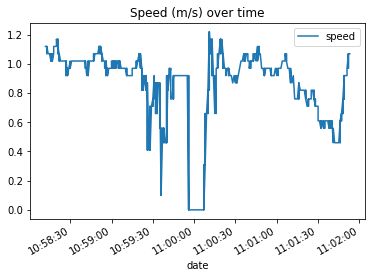

In [39]:
_ = payloads_df.plot(x='date', y='speed', title='Speed (m/s) over time')

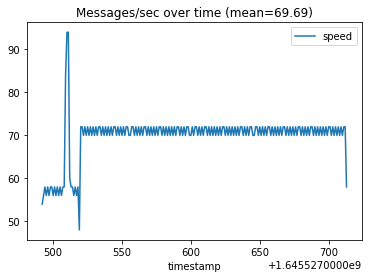

In [40]:
messages_per_sec_over_time = payloads_df[['timestamp', 'speed']].groupby('timestamp').count()
_ = messages_per_sec_over_time.plot(
    title=f'Messages/sec over time (mean={messages_per_sec_over_time.mean().values[0]:0.2f})')

In [41]:
resolution_change_index = []
for i in range(len(payloads)-1):
    if payloads[i]['sonar_trace_data'].shape != payloads[i+1]['sonar_trace_data'].shape:
        resolution_change_index.append(i+1)
# Concat all trace data

trace_data_list = []
if len(resolution_change_index) != 0:
    last_index = 0
    for i in resolution_change_index:
        trace_data_list.append(np.stack([i['sonar_trace_data'] for i in payloads[last_index:i]]))
        last_index = i
    trace_data_list.append(np.stack([i['sonar_trace_data'] for i in payloads[last_index:]]))
else:
    trace_data_concat = np.stack([i['sonar_trace_data'] for i in payloads])

if len(trace_data_list)>0:
    trace_data_concat = trace_data_list[1]

print(f"Data shape : {trace_data_concat.shape}")
print(f"Vmin       : {trace_data_concat.min()}")
print(f"Vmax       : {trace_data_concat.max()}")

Data shape : (150, 2388)
Vmin       : 0
Vmax       : 31744


In [42]:
N_METERS = 10
sample_count = int(trace_data_concat.shape[0] * N_METERS / travel_distance)

sample_count = int(trace_data_concat.shape[0])


pic = trace_data_concat[:sample_count, :sample_count]

#print(f"Small sample (~{N_METERS} meters)")
print(pic.shape)
pic = cv2.normalize(pic, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
pic = cv2.applyColorMap(pic, cv2.COLORMAP_PINK)
pic = cv2.cvtColor(pic, cv2.COLOR_BGR2RGB)
#cv2.imwrite("sonar3.png",pic)
#display(Image.fromarray(pic))


(150, 150)


In [43]:
def find_all_folders_containing_jsf_files(one_root_parameter):
    list_of_folders_containing_jsf = []
    children = [x[0] for x in os.walk(one_root_parameter)]
    for child_folder in children:
        for file in os.listdir(child_folder):
            if file.endswith(".jsf"): 
                list_of_folders_containing_jsf.append(child_folder)
                break
    return list_of_folders_containing_jsf

In [44]:
# Some of this is repurposed code from before
def decode_message(unpacked_struct):
    message = {}
    for i in range(len(unpacked_struct)):
        field_name = header_format[i]['field_name']
        field_value = unpacked_struct[i]
        message[field_name] = field_value
        
    return message

def read_messages_from_file(jsf_filename): # format: "data/20200107101600.jsf"
    messages = []
    with open(jsf_filename, 'rb') as fp:
        while True:
            data = fp.read(struct_len)
            if not data:
                break

            unpacked_struct = struct_unpack(data)
            message = decode_message(unpacked_struct)
            message['payload'] = fp.read(message['payload_length'])
            messages.append(message)
    return messages
        
        
def decode_sonar_trace_data_light(m):
    sonar_message_header_length = 240
    timestamp = np.frombuffer(m['payload'][:4], dtype=np.int32)[0]
    data = m['payload'][sonar_message_header_length:]
    data = np.frombuffer(data, dtype=np.int16)
    scaling_factor = np.frombuffer(m['payload'][168:170], dtype=np.int16)[0]
    data = data.astype(float) * 2.0 ** (-scaling_factor)  # jsf file trick to enhance the resolution, always use this, its required, otherwise the data is choppy
    return {'timestamp': timestamp,
            'sonar_trace_data': data}

def get_starboard_and_port_data_from_messages(input_messages):
    port_payloads = []
    starboard_payloads = []
    for fm in input_messages:
        if fm['message_type'] == 80 and fm['channel'] == 0:
            port_payloads.append(decode_sonar_trace_data_light(fm))
        if fm['message_type'] == 80 and fm['channel'] == 1:
            starboard_payloads.append(decode_sonar_trace_data_light(fm))
            
    port_payloads = sorted(port_payloads, key=lambda date: date['timestamp']) # sorts them by date
    starboard_payloads = sorted(starboard_payloads, key=lambda date: date['timestamp'])
    return [port_payloads,starboard_payloads]
        
def split_into_training_data(configuration,full_unsplit_trace):
    target_folder_path = configuration["output_folder_path"]
    sonar_side = configuration["sonar_side"]
    sample_dims = configuration["output_image_dims"] # Height x width
    sample_overlap = configuration["output_image_overlap"]
    filename_prefix = configuration["filename_prefix"]
    
    dim1 = full_unsplit_trace.shape[0]
    dim2 = full_unsplit_trace.shape[1]

    dim1_full = sample_overlap[0] + sample_dims[0]
    dim2_full = sample_overlap[1] + sample_dims[1]
    sample_index = 0

    bottom_repeat_flag = False # the bottom repeat flag stops the last bottom row from sometimes being duplicated
    # depending on the h and w resolution
    for dim1_count in tqdm(range(0, dim1, sample_dims[0])):
        break_flag = False # the break flag stops the last element of any row being duplicated
        
        for dim2_count in range(0, dim2, sample_dims[1]):
            if break_flag: break
            dim1_iter = dim1_count
            dim2_iter = dim2_count
            if (dim1_iter+dim1_full > dim1): # if its over the edge of the image go from the edge back
                dim1_iter = dim1 - dim1_full # it will overlap but its better than losing content
                bottom_repeat_flag = True
            else:
                bottom_repeat_flag = False
            if (dim2_iter+dim2_full > dim2):  # (probably) FIX THIS; SOMETIMES DUPLICATES
                dim2_iter = dim2 - dim2_full
                break_flag = True
            pic = full_unsplit_trace[dim1_iter:dim1_iter+dim1_full,dim2_iter:dim2_iter+dim2_full]
            if pic.shape[0] != dim1_full or pic.shape[1] != dim2_full:
                print("Error, format of trace:{}".format(full_unsplit_trace.shape))
                print("iteration {}/{} with {} to {} and {} to {}".format(dim1_count,dim2_count,dim1_iter,dim1_iter+dim1_full,dim2_iter,dim2_iter+dim2_full))
                print("incorrect format {} x {}".format(pic.shape[0],pic.shape[1]))

            cv2.imwrite("{}/{}_{}_training_image_{}x{}_{:04d}.png".format(target_folder_path,filename_prefix,sonar_side,dim1_full,dim2_full,sample_index),pic,[cv2.IMWRITE_PNG_COMPRESSION, 0])
            sample_index += 1
        if bottom_repeat_flag: break

def scale_image(open_cv_img,fixed_val_w, dynamic = False):
    height = open_cv_img.shape[0]
    if dynamic:
        width = open_cv_img.shape[1]
        var_borders_regions = [0,int(0.33*width),int(0.66*width),width]
        var_weights_regions = [int(fixed_val_w*0.30),int(fixed_val_w*0.30),int(fixed_val_w*0.40)]
        section_1 = open_cv_img[:,var_borders_regions[0]:var_borders_regions[1]].copy()
        section_2 = open_cv_img[:,var_borders_regions[1]:var_borders_regions[2]].copy()
        section_3 = open_cv_img[:,var_borders_regions[2]:var_borders_regions[3]].copy()

        open_cv_img_hcon = [1,2,3]
        open_cv_img_hcon[0] = cv2.resize(section_1,(var_weights_regions[0],height),interpolation = cv2.INTER_AREA)
        open_cv_img_hcon[1] = cv2.resize(section_2,(var_weights_regions[1],height),interpolation = cv2.INTER_AREA)
        open_cv_img_hcon[2] = cv2.resize(section_3,(var_weights_regions[2],height),interpolation = cv2.INTER_AREA)
        del open_cv_img
        gc.collect()
        open_cv_img_res = cv2.hconcat([open_cv_img_hcon[0],open_cv_img_hcon[1],open_cv_img_hcon[2]])
    else:
        open_cv_img_res = cv2.resize(open_cv_img,(fixed_val_w,height),interpolation = cv2.INTER_AREA)
    return open_cv_img_res

def pad_image_width(input_2d_scan,width_val):
    if width_val == input_2d_scan.shape[1]: return input_2d_scan
    empty_mat = np.zeros((input_2d_scan.shape[0],width_val-input_2d_scan.shape[1]))
    result_arr = cv2.hconcat([input_2d_scan,empty_mat])
    return result_arr

def shift_average(input_list, target_average):
    list_mean = np.nanmean(input_list)
    if list_mean == 0: 
        scale_factor = np.single(0)
    else:
        scale_factor = target_average/list_mean
    scale_factor = scale_factor.astype(float)
    return_list = input_list * scale_factor
    return return_list

def adaptive_norm(input_img_arr1,columns_to_norm_together,norm_max1): # not used anymore due to inferior results
    pic = input_img_arr1
    width = pic.shape[1]
    if columns_to_norm_together == 0:
        cv2.normalize(pic, pic, 0, norm_max1, cv2.NORM_MINMAX)
        return pic
    
    for width_pixel in range(columns_to_norm_together,width,columns_to_norm_together):
        prev_pixel = width_pixel-columns_to_norm_together
        percent_complete = width_pixel / width
        increasing_norm_coeficient = 1.0 #+ percent_complete
        cv2.normalize(pic[:,prev_pixel:width_pixel], pic[:,prev_pixel:width_pixel], 0, norm_max1, cv2.NORM_MINMAX)
    
    cv2.normalize(pic[:,900:], pic[:,900:], 0, norm_max1, cv2.NORM_MINMAX)
    return pic
    

def auto_gain_control(input_img_arr,average_val,mode="rows"):
    #https://chesapeaketech.com/wp-content/uploads/docs/SonarWiz7_UG/HTML/automatic_gain_control__agc_.html
    defined_average = average_val #1.5 used when using min-max norm
    if mode == "rows": #global row average shift
        result_val = np.zeros(input_img_arr.shape)
        img_arr_iter = input_img_arr
        for index,row in enumerate(img_arr_iter):
            result_val[index] = shift_average(row,defined_average)
        return result_val
    else: 
        input_img_arr = np.transpose(input_img_arr)
        result_val = np.zeros(input_img_arr.shape)
        absolute_index = 0
        img_arr_iter = input_img_arr
        for row in img_arr_iter:
            result_val[absolute_index] = shift_average(row,defined_average)
            absolute_index += 1
        result_val = np.transpose(result_val)
        return result_val

def preprocess_image(img_arr):
    target_avg_val = 20 # the higher this is, the "brighter" the image, empircally testing was done to pick a value that is easy for visual data bounding box annotation
    pic2 = img_arr # im lazy
    pic2 = auto_gain_control(pic2,target_avg_val,mode="rows")
    pic2 = auto_gain_control(pic2,target_avg_val,mode="columns")
    
    pic = pic2.astype(np.uint8) # CLAHE reduces file size, so maybe information is lost
    #clahe = cv2.createCLAHE(clipLimit=0.015, tileGridSize=(8,8)) #the clip limit is the most important (ive read)
    # i found two papers one of them had best results with 0.01 the other 0.025, so i just guestimated a value kind of
    #pic = clahe.apply(pic)
    
    pic = cv2.applyColorMap(pic, cv2.COLORMAP_PINK)
    open_cv_original_img = cv2.cvtColor(pic, cv2.COLOR_BGR2GRAY)
    return open_cv_original_img

def jsf_files_to_images_from_folder(jsf_file_folder,output_folder_path,output_image_dims=None,output_image_overlap=0):
    index2side = ["port","starboard"]
    if not os.path.exists("{}/img_outputs/training_data".format(output_folder_path)): # make a folder for the training data if it doesnt exist
        os.makedirs("{}/img_outputs/training_data".format(output_folder_path))
        
    file_messages = []
    print("Reading all jsf files...")
    for file in os.listdir(jsf_file_folder):
        if file.endswith(".jsf"):
            file_messages = file_messages + read_messages_from_file("{}/{}".format(jsf_file_folder,file))
            
    combined_array = get_starboard_and_port_data_from_messages(file_messages) # get all the data from both sides of the scan from all files

    for side_index,side_data in enumerate(combined_array): # first do one side then the other from all files  (port and starboard)
        if not side_data: continue
        trace_data_list = []
        resolution_change_index = []
        for i in range(len(side_data)-1): # side data is a list of every sonar reading, think of it like iterating an image row by row, but rows can have different widths
            if side_data[i]['sonar_trace_data'].shape != side_data[i+1]['sonar_trace_data'].shape: # if width is different between row N and row N+1 save the index of row N+1
                resolution_change_index.append(i+1)
        if resolution_change_index: # detect width changes, find max width of all readings (used to pad image widhts with black later, so they are not resized differently)
            max_width = 0
            last_index = 0          
            for i in resolution_change_index:
                stacked_image = np.stack([same_width_reading_data['sonar_trace_data'] for same_width_reading_data in side_data[last_index:i]])
                if stacked_image.shape[1] > max_width: max_width = stacked_image.shape[1]
                trace_data_list.append(stacked_image)
                last_index = i
            stacked_image = np.stack([same_width_reading_data['sonar_trace_data'] for same_width_reading_data in side_data[last_index:]])
            if stacked_image.shape[1] > max_width: max_width = stacked_image.shape[1]
            trace_data_list.append(stacked_image) # list containing seperate matrices of stacked readings that each have the same width, so if there are 2 different widths in all readings, this has 2 elements, example below
            # sonar_lines = [0,1,2,3,4,5,6] # imagine each number is a sonar reading with its own width
            # resolution_change_index = [2,4]
            # result (trace_data_list = [[0,1],[2,3],[4,5,6]] # each of these has same width
        else:
            stacked_image = np.stack([same_width_reading_data['sonar_trace_data'] for same_width_reading_data in side_data]) # if all reading widths of all readings in all files are the same (unlikely) just stack 'em
            max_width = stacked_image.shape[1]
            trace_data_list.append(np.stack(stacked_image))
        
        print("Starting to stitch matrix...")
        stitched_resized_list = []
        for index,differing_width_scan in enumerate(trace_data_list): # pad all readings with 0's (black) so they have max width, then scale that down to 1000 width so it is uniformly rescaled
            padded_image = pad_image_width(differing_width_scan,max_width)
            manipulated_scaled_image = scale_image(padded_image,1000,dynamic = False)
            stitched_resized_list.append(manipulated_scaled_image)
            
        stitched_resized_img = np.concatenate(stitched_resized_list)  # concatenate the images into one very high image since the images now all have the same width, (they were uniformly scaled down to 1000 width due to the padding method used)
        pic = preprocess_image(stitched_resized_img) # applies row and column wise pixel average shifting, this makes the entire image more uniformly lit, so that darker areas are as visible as lighter ones
        print("Creating image...")
        jsf_file_folder = jsf_file_folder.replace("\\","/")
        file_name_prefix =  "{}_{}".format(jsf_file_folder.split("/")[-1],jsf_file_folder.split("/")[-2])
        # the below call saves the entire enormous stitched full sonar survey image
        cv2.imwrite("{}/img_outputs/{}_{}_sonar_output.png".format(output_folder_path,file_name_prefix,index2side[side_index]),pic,[cv2.IMWRITE_PNG_COMPRESSION, 0])
        if output_image_dims is not None:
            config_dict = {
                "output_folder_path": "{}/img_outputs/training_data".format(output_folder_path),
                "filename_prefix": file_name_prefix,
                "sonar_side":index2side[side_index],
                "output_image_dims":output_image_dims,
                "output_image_overlap":output_image_overlap
            }
            split_into_training_data(config_dict,pic) # splits the entire enormous stitched full sonar survey image into dimensions with the padding specified ( 1000x1000 images with 200 pixel overlap was used for the work)
        print("{} {} done".format(file_name_prefix,index2side[side_index]))


In [45]:
# the training split percentages sometimes dont complete this is normal (they do actually complete)   
#-------------------------------------height (y step) x width (x step) padding (+ amount of pixels overlaping)
if True:
    output_folder = "C:/Users/zanza/Desktop/MSC_work/Msc_Obj_Det/data/unused_samples"
    root_data_tiny_test = find_all_folders_containing_jsf_files(output_folder) # gets list of surveys (each survey has more .jsf files)
    print(root_data_tiny_test)
    for jsf_folder in root_data_tiny_test:
        jsf_files_to_images_from_folder(jsf_folder,output_folder,[800,1000],(200,0))

['C:/Users/zanza/Desktop/MSC_work/Msc_Obj_Det/data/unused_samples']
Reading all jsf files...
Starting to stitch matrix...
Creating image...


 90%|█████████ | 18/20 [00:00<00:00, 25.70it/s]


unused_samples_data port done
Starting to stitch matrix...
Creating image...


 90%|█████████ | 18/20 [00:00<00:00, 24.66it/s]


unused_samples_data starboard done


In [46]:
# It worked! now for the full dataset TODO(here everything could be included, even surveys with no bodies, they could be used as backgrounds for fake bodies)
if False:
    output_folder = "D:/full_data/data_likely_containing_targets"
    root_data_tiny_test = find_all_folders_containing_jsf_files(output_folder)
    root_data_tiny_test.reverse()
    print(root_data_tiny_test)
    for jsf_folder in root_data_tiny_test:
        jsf_files_to_images_from_folder(jsf_folder,output_folder,[800,1000],(200,0))

In [47]:
# misc stuff
from urllib.parse import unquote
import copy
import pprint

def get_class_stats(vott_csv):
    vott_csv = pd.read_csv(vott_csv)
    coverage_dict = dict()
    for index,something in vott_csv.iterrows():
        real_name = unquote(something["image"])
        part = real_name.split("_data_likely_containing_targets_")
        part = part[0]
        if "_data_likely_containing_targets_" not in real_name:
            part = real_name.split("_training_image_")
            part = part[0]
            part = part.split("_")[:-1]
            part = "_".join(part)
        if part not in coverage_dict:
            coverage_dict[part] = {
                "bike" : 0,
                "debris" : 0,
                "confirmed_body": 0,
                "anomaly": 0
            }
        coverage_dict[part][something["label"]] += 1
    return coverage_dict

def vott_csv_to_labelme_proj_json(source,target): # Not finished and not used, stuck with vott in the end even though it kind of sucks
    vott_csv = pd.read_csv(source)
    target_json = pd.read_json(target)
    new_names = []
    name_to_info = dict()
    for index,something in vott_csv.iterrows():
        real_name = unquote(something["image"])
        new_names.append(real_name)
        name_to_info[real_name] = { 
            "xmin": something["xmin"],
            "ymin": something["ymin"],
            "xmax": something["xmax"],
            "ymax": something["ymax"],
            "label": something["label"]
        }
    json_copy = copy.deepcopy(target_json)
    for key,value in target_json.items():
        name = value["filename"]
        if name in new_names:
            region_skeleton = {
                "shape_attributes": {
                    "name": "rect",
                    "x": 299,
                    "y": 237,
                    "width": 126,
                    "height": 56
                },
                "region_attributes": {
                "confirmed_body": ""
                }
            }
            json_copy[key]["regions"]

prefix = "C:/Users/Moji podatki/Desktop/github/Msc_Obj_Det/data/vott/run3_big/output/vott-csv-export/"
target = "empty_vgg_json.json"
source = "source_vott_csv.csv"

target_folder = "C:/Users/Moji podatki/Desktop/github/Msc_Obj_Det/data/vott/run3_big/input"
csv_proj_file = "C:/Users/zanza/Desktop/MSC_work/Msc_Obj_Det/data/vott/run3_big/output/vott-csv-export/06_02_2022_BIG-export_before_synth_added.csv" # todo do after synth added too


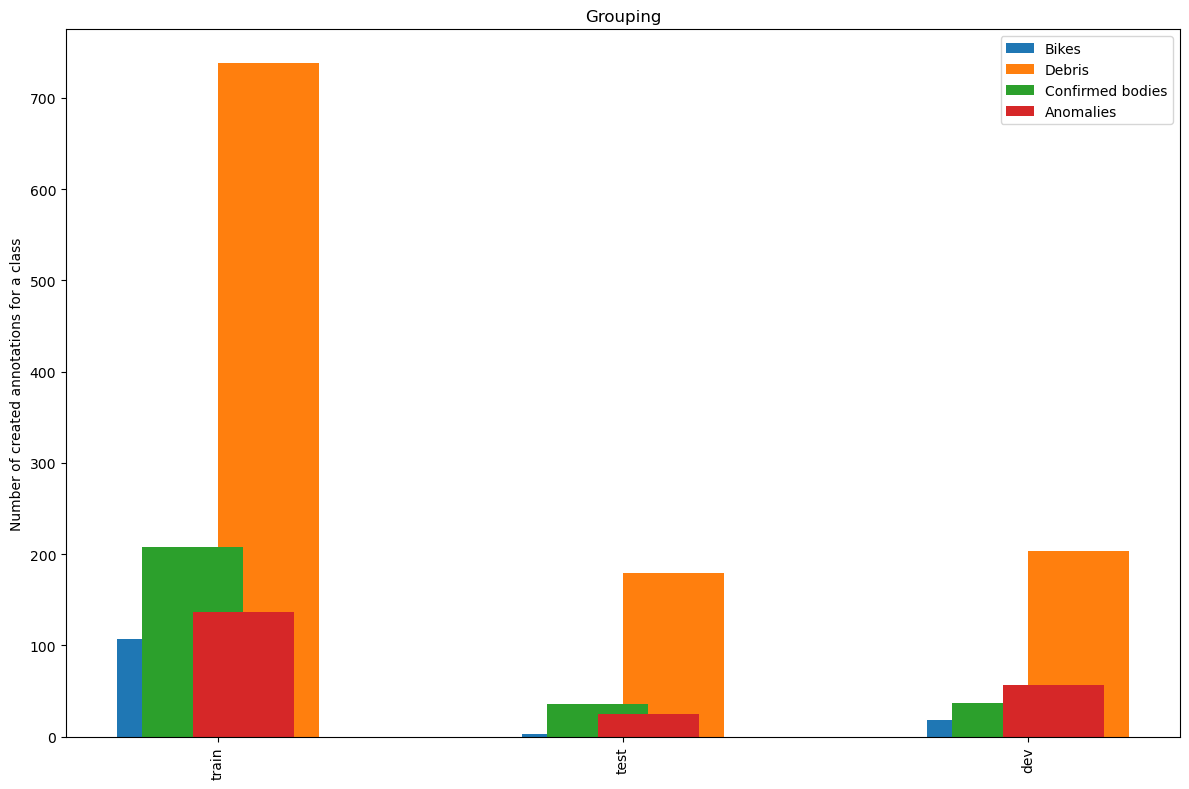

Sum annotated bodies:281, anomalies:219, debris:1120, bikes:128


<Figure size 1200x800 with 0 Axes>

In [48]:
info_dict = get_class_stats(csv_proj_file)
vott_csv = pd.read_csv(csv_proj_file)

you_want_to_go_over_confirmed_bodies_in_specified_folder = False
folder_with_imgs = "C:/Users/zanza/Desktop/MSC_work/Msc_Obj_Det/data/vott/run3_big/output/vott-csv-export/only_imgs_with_bodies/"
if you_want_to_go_over_confirmed_bodies_in_specified_folder: # go over all the confirmed bodies in above folder (opens them in default image viewer of your machine)
    for index,something in vott_csv.iterrows():
        real_name = something["image"]
        if not something["label"] == "confirmed_body": continue
        path = folder_with_imgs+real_name
        im = Image.open(path)
        # This method will show image in any image viewer
        print(unquote(something["image"]))
        print("{},{}".format(something["xmin"],something["ymin"]))
        im.show()
        wait_txt = input("Press enter to continue")

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100
c_bikes = 0
c_debris = 0
c_cnf_body = 0
c_anomaly = 0

train_set = [ # TODO these dont include the newly added data (2nd batch with 4-5 runs)
    '03-01-2020 Hoogezand, winschoterdiep',
    '09-06-2020 Velden',
    '16-08-20 Reuver',
    '22-03-2020 weert_2',
    '22-03-2020 weert',
    '20-03-2020 weert_2',
    '20-03-2020 weert',
    '24-05-2020 Honselaarsplas',
    '29-06-2020 winterswijk',
    'maarseveen',
    '09-07-2020 Giesbeek',
    '30-06-2020 Giesbeek'
]
test_set = [
    '06-12-2020 Burdaard',
    '09-11-2020 wemeldinge_2',
    '09-11-2020 wemeldinge',
    'brummen',
    'Coverage_12-11-2020 Brummen'
]
dev_set = [
    '18-09-2020 stavoren',
    '27-03-2020 sluis Belfeld',
    '20-06-2020 Lemmer',
    '28-07-2020 Maastricht',
    '14-03-2020 breukelen'
]

labels = ["train","test","dev"]
bikes = [0,0,0]
debris = [0,0,0]
confirmed_body = [0,0,0]
anomaly = [0,0,0]

for key, value in info_dict.items():
    sample_index = 0 # training set
    if key in test_set:
        sample_index = 1
    if key in dev_set:
        sample_index = 2

    bikes[sample_index] += value["bike"]
    debris[sample_index] += value["debris"]
    confirmed_body[sample_index] += value["confirmed_body"]
    anomaly[sample_index] += value["anomaly"]

    c_bikes += value["bike"]
    c_debris += value["debris"]
    c_cnf_body += value["confirmed_body"]
    c_anomaly += value["anomaly"]

x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, bikes, width, label='Bikes')
rects2 = ax.bar(x + width/2, debris, width, label='Debris')
rects3 = ax.bar(x - width/4, confirmed_body, width, label='Confirmed bodies')
rects4 = ax.bar(x + width/4, anomaly, width, label='Anomalies')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of created annotations for a class')
ax.set_title('Grouping')
ax.set_xticks(x) # values
ax.set_xticklabels(labels) # labels
plt.xticks(rotation=90)
ax.legend()
fig.tight_layout()
plt.show()
plt.savefig('DatasetDistributions.png', bbox_inches='tight')
print("Sum annotated bodies:{}, anomalies:{}, debris:{}, bikes:{}".format(c_cnf_body,c_anomaly,c_debris,c_bikes))